In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten,Conv2D,MaxPooling2D,Dropout
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical


In [ ]:
(x_train,y_train),(x_test,y_test)=fashion_mnist.load_data()
print('Training images shape',x_train.shape)
print('Training labels shape',y_train.shape)
print('Testing images shape',x_test.shape)
print('Testing labels shape',y_test.shape)

Training images shape (60000, 28, 28)
Training labels shape (60000,)
Testing images shape (10000, 28, 28)
Testing labels shape (10000,)


In [ ]:
class_names=['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']

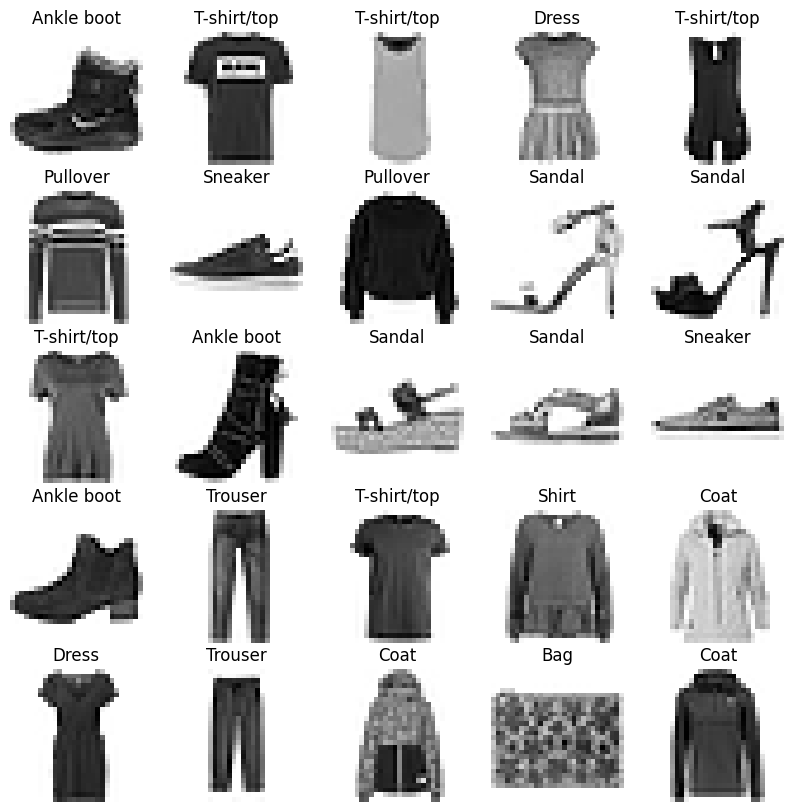

In [ ]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_train[i],cmap=plt.cm.binary)
    plt.title(class_names[np.argmax(y_train[i])])
    plt.axis('off')
plt.show()

In [ ]:
x_train=x_train/255.0
x_test=x_test/255.0

In [ ]:
x_train=x_train.reshape(-1,28,28,1)
x_test=x_test.reshape(-1,28,28,1)

In [ ]:
y_train=to_categorical(y_train,10)
y_test=to_categorical(y_test,10)

In [ ]:
print('Training images shape',x_train.shape)
print('Training labels shape',y_train.shape)
print('Testing images shape',x_test.shape)
print('Testing labels shape',y_test.shape)

Training images shape (60000, 28, 28, 1)
Training labels shape (60000, 10)
Testing images shape (10000, 28, 28, 1)
Testing labels shape (10000, 10)


In [ ]:
print(type(x_train))
print(type(y_train))
print(type(x_test))
print(type(y_test))
print (x_train.dtype)
print (y_train.dtype)
print (x_test.dtype)
print (y_test.dtype)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
float64
float64
float64
float64


In [ ]:
model=Sequential()
#1st convolution layer
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
#first pooling layr
model.add(MaxPooling2D((2,2)))
#2nd conv layr
model.add(Conv2D(64,(3,3),activation='relu'))
#2nd pooling layr
model.add(MaxPooling2D((2,2)))
#flatten
model.add(Flatten())
#1st dense layer
model.add(Dense(128,activation='relu'))
#dropout
model.add(Dropout(0.5))
#output layr
model.add(Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history=model.fit(x_train,y_train,epochs=10,batch_size=32, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7899 - loss: 0.5911 - val_accuracy: 0.8616 - val_loss: 0.3825
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8640 - loss: 0.3846 - val_accuracy: 0.8874 - val_loss: 0.3042
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8816 - loss: 0.3278 - val_accuracy: 0.8943 - val_loss: 0.2927
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8907 - loss: 0.2993 - val_accuracy: 0.9014 - val_loss: 0.2621
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8987 - loss: 0.2756 - val_accuracy: 0.9062 - val_loss: 0.2557
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9055 - loss: 0.2546 - val_accuracy: 0.9081 - val_loss: 0.2511
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9127 - loss: 0.2377 - val_accuracy: 0.9077 - val_loss: 0.2493
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9173 - loss: 0.2243 - 

In [ ]:
test_loss,test_accuracy = model.evaluate(x_test,y_test)
print("Test Loss",test_loss)
print("Test Accuracy",test_accuracy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9121 - loss: 0.2458
Test Loss 0.24584735929965973
Test Accuracy 0.9121000170707703


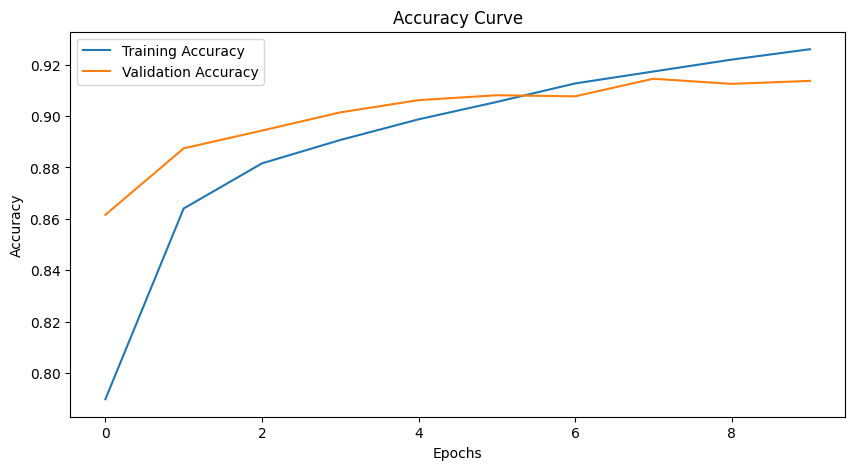

In [ ]:
#Accuracy curve
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()
plt.show()

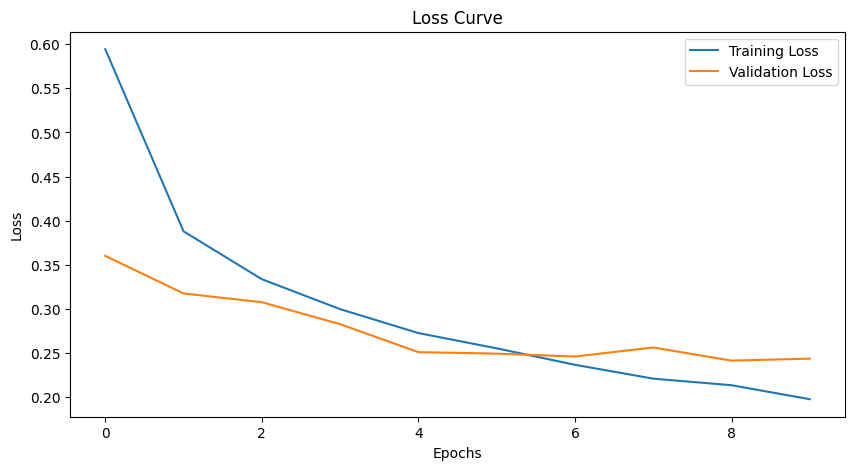

In [ ]:
#loss curve
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step
Predicted class: Ankle boot
Actual class: Ankle boot


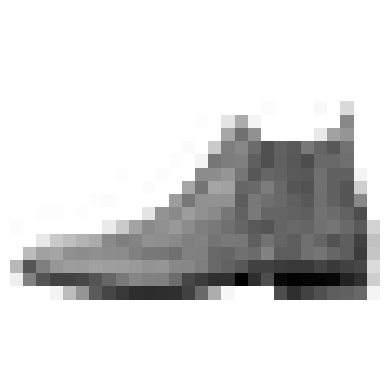

In [ ]:
sample=x_test[0]
prediction=model.predict(sample.reshape(1,28,28,1))
predicted_class=np.argmax(prediction)
actual_class=np.argmax(y_test[0])
print('Predicted class:',class_names[predicted_class])
print('Actual class:',class_names[actual_class])
plt.imshow(sample.reshape(28,28),cmap=plt.cm.binary)
plt.axis('off')
plt.show()

Saving images.jpg to images (1).jpg


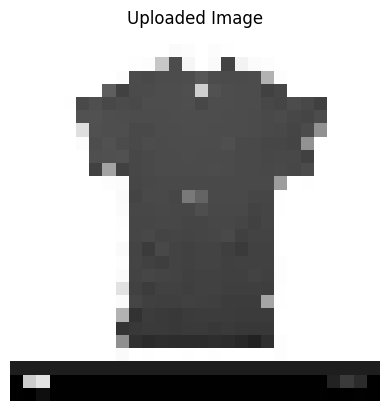

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predicted Fashion Item : Shirt
Confidence score: 94.2202 %


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import cv2
uploaded=files.upload()
file_path=list(uploaded.keys())[0]
img=cv2.imread(file_path,cv2.IMREAD_GRAYSCALE)
img=cv2.resize(img,(28,28))

#invert colors


#Normalize
img=img.astype('float32')/255.0

#display
plt.imshow(img,cmap='gray')
plt.title('Uploaded Image')
plt.axis('off')
plt.show()


#reshape
img=img.reshape(1,28,28,1)

#predict
prediction=model.predict(img)
predicted_class=np.argmax(prediction)
print('Predicted Fashion Item :',class_names[predicted_class])

#print confidence code
print('Confidence score:',np.max(prediction)*100,'%')